In [1]:
import pandas as pd

# Load Sensor Logs- Already in IST

In [2]:
logs = pd.read_json('harshpreet_system_logs.jsonl', lines = True)

In [3]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [4]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-10 01:29:34.585978200+05:30,46.2,23,28.3,2876.93,76.54,193,283
1,2026-07-10 01:29:37.613914200+05:30,33.3,16,26.4,2197.08,76.85,194,282
2,2026-07-10 01:29:39.701136+05:30,36.0,17,26.2,2918.38,76.64,194,284
3,2026-07-10 01:29:41.756425+05:30,30.0,20,27.7,2495.55,76.74,194,285
4,2026-07-10 01:29:43.791446600+05:30,24.6,9,27.7,2644.79,76.85,194,285


# Load Stress Events - UTC Format (Z)

In [5]:
events = pd.read_json("harshpreet_stress_events.jsonl", lines = True)

In [6]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [7]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,SYSTEM,0,0,2026-07-10 01:30:11.141482800+05:30,2026-07-10 01:30:11.141482800+05:30,0,101,Automatic stress experiment started.
1,SESSION,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,INITIAL_IDLE,0,0,2026-07-10 01:30:11.157078200+05:30,2026-07-10 01:32:11.162513400+05:30,120,101,Idle or cooling session completed.
2,WORKLOAD_STEP,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,0,1,2026-07-10 01:32:11.167500400+05:30,2026-07-10 01:33:30.170704600+05:30,79,101,Completed workload step.
3,WORKLOAD_STEP,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,0,2,2026-07-10 01:33:30.210165200+05:30,2026-07-10 01:34:36.212408700+05:30,66,101,Completed workload step.
4,WORKLOAD_STEP,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,20,3,2026-07-10 01:34:36.212408700+05:30,2026-07-10 01:38:27.217497700+05:30,231,101,Completed workload step.


In [8]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [9]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [10]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuAverageClock,ramUsage,networkConnections,processCount
0,2026-07-10 01:29:34.585978200+05:30,46.2,23,28.3,2876.93,76.54,193,283
1,2026-07-10 01:29:37.613914200+05:30,33.3,16,26.4,2197.08,76.85,194,282
2,2026-07-10 01:29:39.701136+05:30,36.0,17,26.2,2918.38,76.64,194,284
3,2026-07-10 01:29:41.756425+05:30,30.0,20,27.7,2495.55,76.74,194,285
4,2026-07-10 01:29:43.791446600+05:30,24.6,9,27.7,2644.79,76.85,194,285


In [11]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,SYSTEM,0,0,2026-07-10 01:30:11.141482800+05:30,2026-07-10 01:30:11.141482800+05:30,0,101,Automatic stress experiment started.
1,SESSION,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,INITIAL_IDLE,0,0,2026-07-10 01:30:11.157078200+05:30,2026-07-10 01:32:11.162513400+05:30,120,101,Idle or cooling session completed.
2,SESSION,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,0,62,2026-07-10 01:32:11.165510800+05:30,2026-07-10 03:02:11.167764100+05:30,5400,101,Workload session completed.
3,WORKLOAD_STEP,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,0,1,2026-07-10 01:32:11.167500400+05:30,2026-07-10 01:33:30.170704600+05:30,79,101,Completed workload step.
4,WORKLOAD_STEP,Harshpreet_2026-07-09T20-00-11-093700500Z,Harshpreet,RAMP,0,2,2026-07-10 01:33:30.210165200+05:30,2026-07-10 01:34:36.212408700+05:30,66,101,Completed workload step.


In [12]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-10 01:29:34.585978200+05:30
Sensor end:   2026-07-10 09:19:15.414141+05:30


In [13]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-10 01:30:11.141482800+05:30
Event end:   2026-07-10 09:19:45.002055800+05:30


In [15]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [16]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                      runId    deviceId          mode  targetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  Harshpreet_2026-07-09T20-00-11-093700500Z  Harshpreet        SYSTEM           0           0 2026-07-10 01:30:11.141482800+05:30 2026-07-10 01:30:11.141482800+05:30                      0   101  Automatic stress experiment started.
1        SESSION  Harshpreet_2026-07-09T20-00-11-093700500Z  Harshpreet  INITIAL_IDLE           0           0 2026-07-10 01:30:11.157078200+05:30 2026-07-10 01:32:11.162513400+05:30                    120   101    Idle or cooling session completed.
2        SESSION  Harshpreet_2026-07-09T20-00-11-093700500Z  Harshpreet          RAMP           0          62 2026-07-10 01:32:11.165510800+05:30 2026-07-10 03:02:11.167764100+05:30                   5400   101           Workload session completed.
3  W

# Cleaning the Stress Intervals

In [17]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 301


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-10 01:30:11.157078200+05:30,2026-07-10 01:32:11.162513400+05:30,INITIAL_IDLE,0,0,SESSION
1,2026-07-10 01:32:11.165510800+05:30,2026-07-10 03:02:11.167764100+05:30,RAMP,0,62,SESSION
2,2026-07-10 01:32:11.167500400+05:30,2026-07-10 01:33:30.170704600+05:30,RAMP,0,1,WORKLOAD_STEP
3,2026-07-10 01:33:30.210165200+05:30,2026-07-10 01:34:36.212408700+05:30,RAMP,0,2,WORKLOAD_STEP
4,2026-07-10 01:34:36.212408700+05:30,2026-07-10 01:38:27.217497700+05:30,RAMP,20,3,WORKLOAD_STEP
5,2026-07-10 01:38:27.218495500+05:30,2026-07-10 01:39:05.224412600+05:30,RAMP,20,4,WORKLOAD_STEP
6,2026-07-10 01:39:05.225421100+05:30,2026-07-10 01:42:20.233902600+05:30,RAMP,40,5,WORKLOAD_STEP
7,2026-07-10 01:42:20.235353400+05:30,2026-07-10 01:44:45.242171100+05:30,RAMP,40,6,WORKLOAD_STEP
8,2026-07-10 01:44:45.243421200+05:30,2026-07-10 01:45:13.264194700+05:30,RAMP,60,7,WORKLOAD_STEP
9,2026-07-10 01:45:13.265550900+05:30,2026-07-10 01:45:49.271618200+05:30,RAMP,60,8,WORKLOAD_STEP


In [18]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 293
Idle/cooling sessions: 4

Workload modes:
mode
MIXED         113
RAMP           62
TRANSITION     62
CHAOS          56
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                1
COOLING_AFTER_RAMP          1
COOLING_AFTER_CHAOS         1
COOLING_AFTER_TRANSITION    1
Name: count, dtype: int64


In [19]:
import numpy as np

In [20]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ============================================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"


# ============================================================
# 3. IMPUTE ZERO TEMPERATURE READINGS
# ============================================================

zero_temp_mask = merged["cpuTemperature"] == 0
zero_temp_count = int(zero_temp_mask.sum())

if zero_temp_count > 0:
    merged.loc[zero_temp_mask, "cpuTemperature"] = np.nan
    merged["cpuTemperature"] = (
        merged["cpuTemperature"]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )
    print(f"Imputed {zero_temp_count} zero-temperature rows.")


Imputed 2 zero-temperature rows.


In [21]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (13819, 12)

Mode distribution:
mode
MIXED                       5303
CHAOS                       2655
TRANSITION                  2648
RAMP                        2631
COOLING_AFTER_RAMP           148
COOLING_AFTER_CHAOS          148
COOLING_AFTER_TRANSITION     148
UNASSIGNED                    79
INITIAL_IDLE                  59
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13237
SESSION            503
None                79
Name: count, dtype: int64

Unassigned samples:
79


In [22]:
# experiment_start = events.loc[
#     events["eventType"] == "RUN",
#     "startTime"
# ].iloc[0]

# experiment_end = events.loc[
#     events["eventType"] == "RUN",
#     "endTime"
# ].iloc[0]


# merged.loc[
#     merged["timestamp"] < experiment_start,
#     "mode"
# ] = "PRE_EXPERIMENT"


# merged.loc[
#     merged["timestamp"] >= experiment_end,
#     "mode"
# ] = "POST_EXPERIMENT"

In [23]:
merged.to_csv(
    "harshpreet_merged_experiment.csv",
    index=False
)

print("Saved: harshpreet_merged_experiment.csv")

Saved: harshpreet_merged_experiment.csv


In [24]:
import matplotlib.pyplot as plt

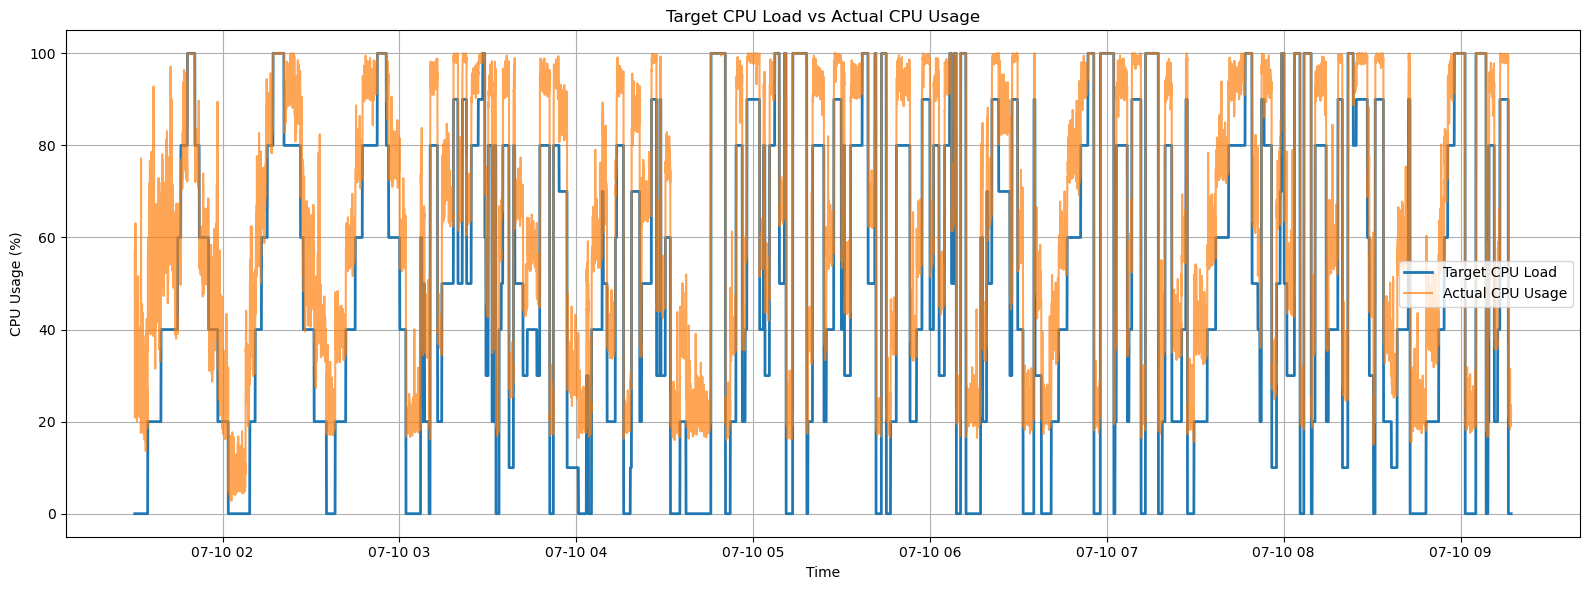

In [25]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 14.700414847161573
Correlation: 0.9737337122567293


In [27]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,2424,21.770627,7.361585,19.274340
1,10.0,333,29.866667,5.688024,16.896396
2,20.0,1806,39.454596,7.691009,17.411960
3,30.0,558,48.277419,4.672801,16.163082
4,40.0,1639,56.985418,6.671507,16.517999
5,50.0,759,67.233070,4.814221,15.380764
6,60.0,816,72.879779,7.771030,15.292279
7,70.0,310,85.037097,4.073850,14.461290
8,80.0,2368,91.939189,5.453646,15.325169
9,90.0,1085,98.187742,4.374029,13.896774


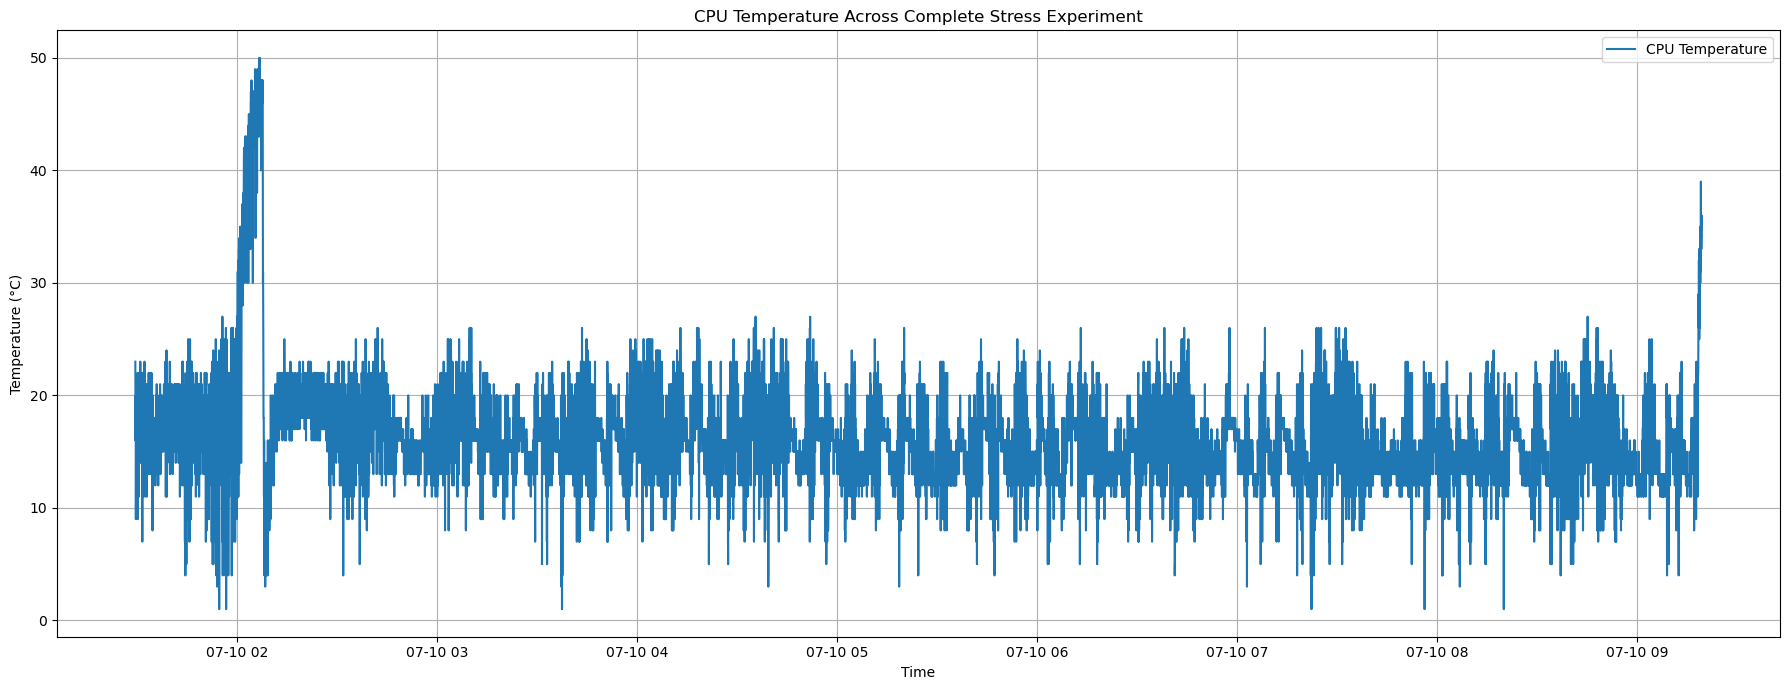

In [28]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-10 01:29:34.585978200+05:30,UNASSIGNED
18,2026-07-10 01:30:12.469169600+05:30,INITIAL_IDLE
77,2026-07-10 01:32:12.794934500+05:30,RAMP
2708,2026-07-10 03:02:12.277329100+05:30,COOLING_AFTER_RAMP
2856,2026-07-10 03:07:11.954673500+05:30,CHAOS
5511,2026-07-10 04:37:12.619527100+05:30,COOLING_AFTER_CHAOS
5659,2026-07-10 04:42:12.361957500+05:30,TRANSITION
8307,2026-07-10 06:12:11.937885800+05:30,COOLING_AFTER_TRANSITION
8455,2026-07-10 06:17:11.587680200+05:30,MIXED
13758,2026-07-10 09:17:12.601487300+05:30,UNASSIGNED


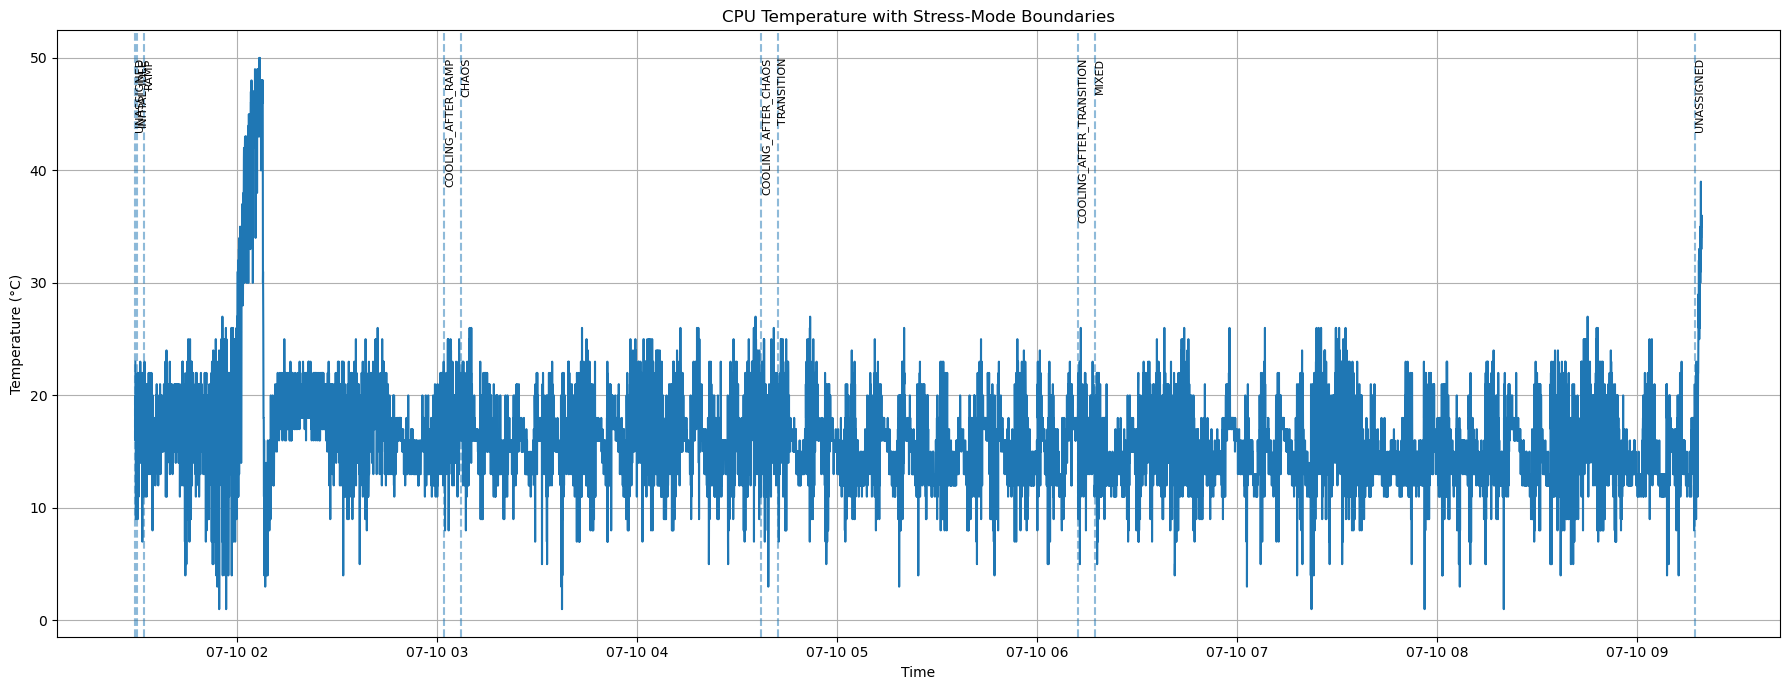

In [30]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
analysis_cols = [
    "cpuUsage",
    "cpuPackagePower",
    "cpuAverageClock",
    "cpuTemperature"
]

correlation = (
    merged[analysis_cols]
    .corr()
)

display(correlation)

,cpuUsage,cpuPackagePower,cpuAverageClock,cpuTemperature
cpuUsage,1.000000,0.294268,-0.557111,-0.359584
cpuPackagePower,0.294268,1.000000,0.268847,-0.688238
cpuAverageClock,-0.557111,0.268847,1.000000,-0.149283
cpuTemperature,-0.359584,-0.688238,-0.149283,1.000000


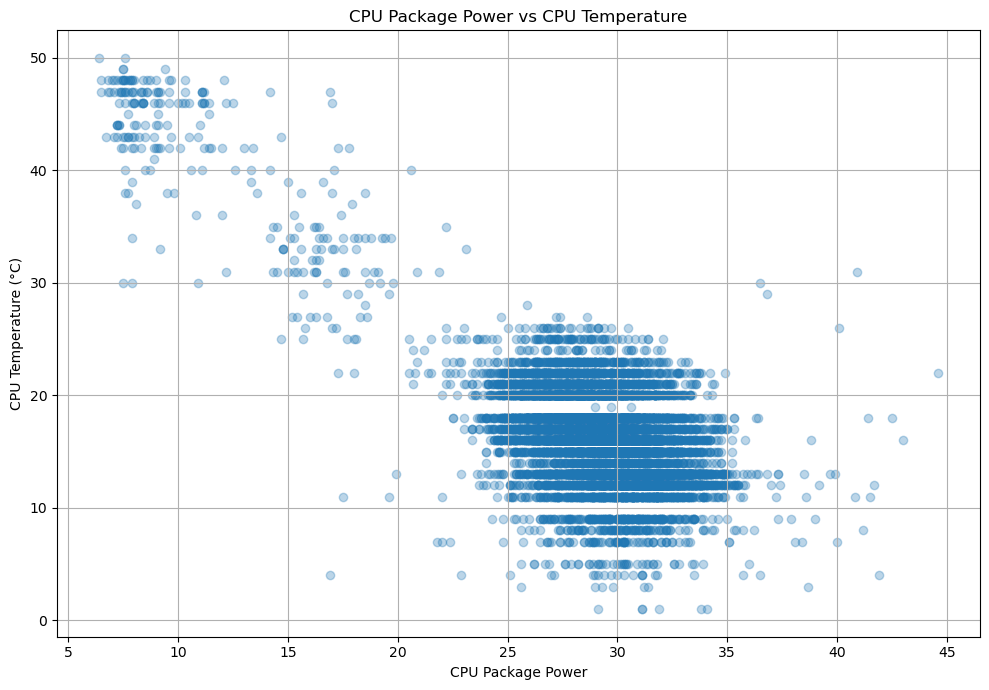

In [32]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

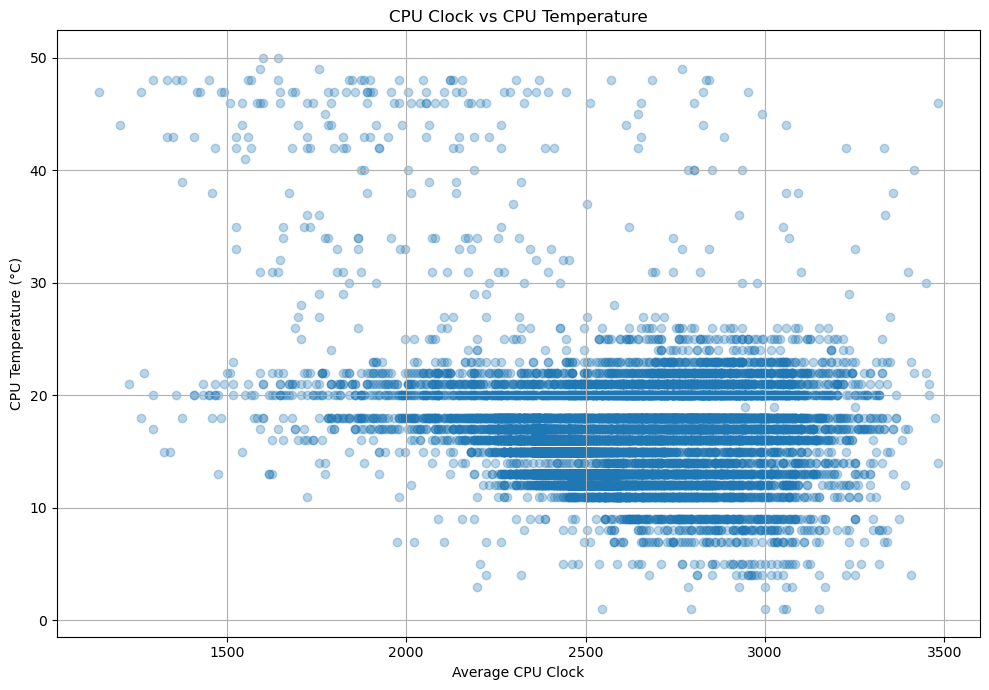

In [33]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

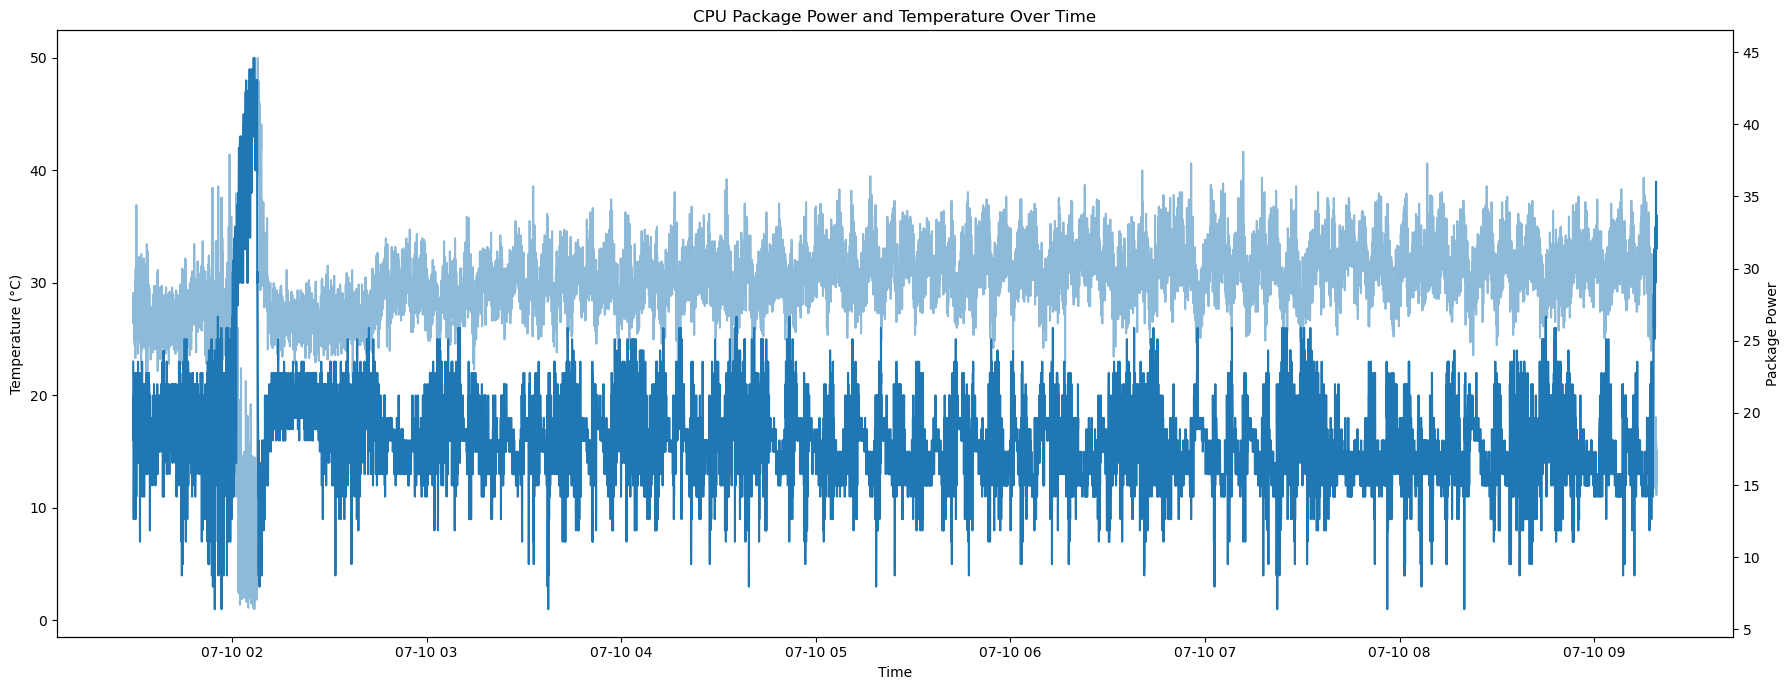

In [34]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [35]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 444
mode
COOLING_AFTER_RAMP          148
COOLING_AFTER_CHAOS         148
COOLING_AFTER_TRANSITION    148
Name: count, dtype: int64


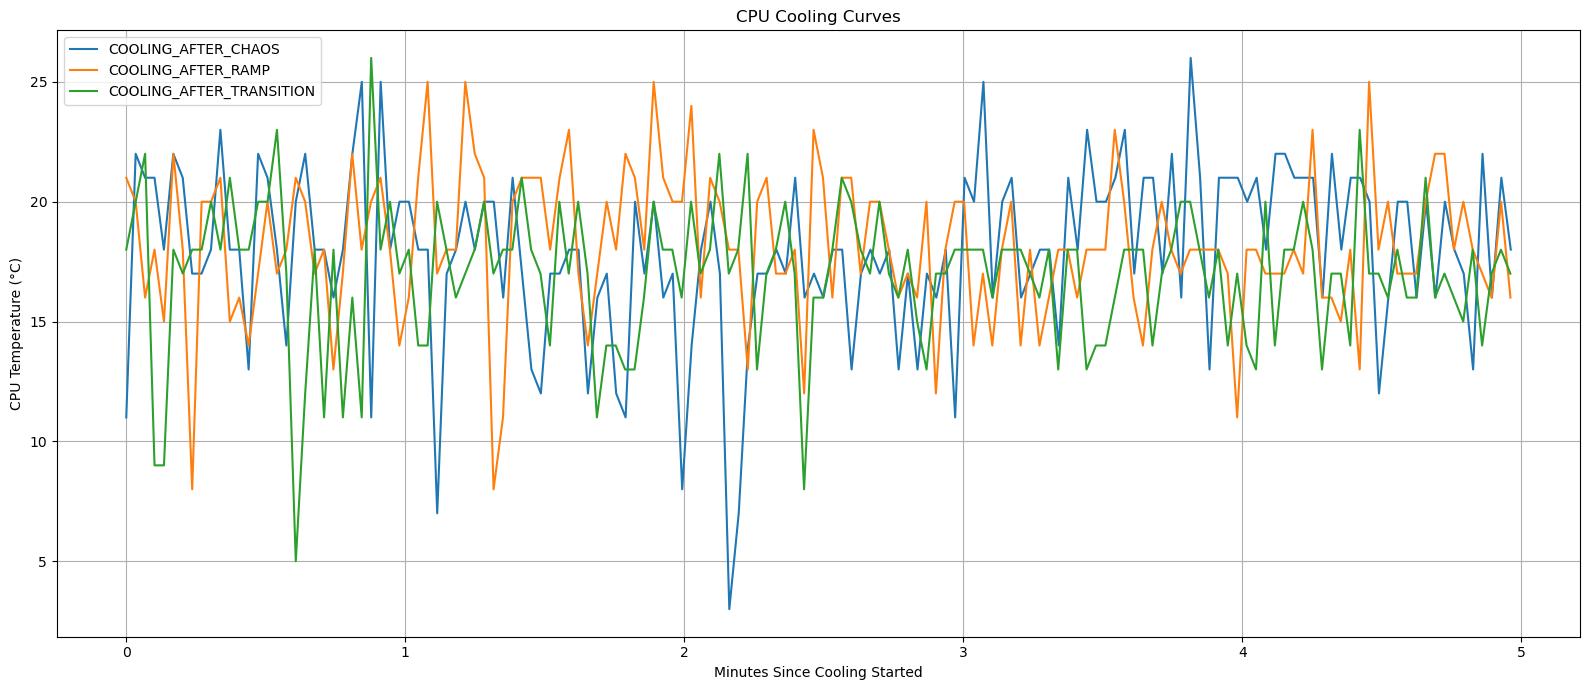

In [36]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,11.0,18.0,-7.0,4.961974,-1.410729
1,COOLING_AFTER_RAMP,21.0,16.0,5.0,4.960836,1.007895
2,COOLING_AFTER_TRANSITION,18.0,17.0,1.0,4.960482,0.201593


In [38]:
# Sort by time
df = merged.sort_values("timestamp").reset_index(drop=True).copy()

# Your data is sampled roughly every 2 seconds
# 20 seconds ≈ 10 rows ahead
HORIZON_STEPS = 10

# Temperature 20 seconds into the future
df["futureTemperature"] = df["cpuTemperature"].shift(-HORIZON_STEPS)

# Exact target used conceptually by your model
df["delta_t"] = (
    df["futureTemperature"] - df["cpuTemperature"]
)

# Remove final rows where future temperature is unavailable
delta_df = df.dropna(subset=["delta_t"]).copy()

print("========== MANAN DELTA T ANALYSIS ==========")
print(delta_df["delta_t"].describe())

print("\nPercentage |Delta T| <= 1°C:")
print((delta_df["delta_t"].abs() <= 1).mean() * 100, "%")

print("\nPercentage Delta T == 0°C:")
print((delta_df["delta_t"] == 0).mean() * 100, "%")

print("\nPercentage Delta T > 4°C:")
print((delta_df["delta_t"] > 4).mean() * 100, "%")

print("\nMost common Delta T values:")
print(delta_df["delta_t"].value_counts().head(15))

========== MANAN DELTA T ANALYSIS ==========
count    13809.000000
mean         0.013252
std          4.288090
min        -35.000000
25%         -2.000000
50%          0.000000
75%          2.000000
max         23.000000
Name: delta_t, dtype: float64

Percentage |Delta T| <= 1°C:
40.560504019117964 %

Percentage Delta T == 0°C:
19.487290897240932 %

Percentage Delta T > 4°C:
12.158737055543487 %

Most common Delta T values:
delta_t
 0.0    2691
-1.0    1587
 1.0    1323
-2.0    1136
 2.0     971
-3.0     852
 3.0     765
 4.0     647
-4.0     613
 5.0     544
-5.0     473
 6.0     267
-6.0     259
 7.0     229
-7.0     224
Name: count, dtype: int64


In [39]:
mode_analysis = (
    delta_df
    .groupby("mode")["delta_t"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("count", ascending=False)
)

display(mode_analysis)

,count,mean,median,std,min,max
mode,,,,,,
MIXED,5303,0.005846,0.0,4.148662,-18.0,21.0
CHAOS,2655,0.002637,0.0,4.289253,-15.0,19.0
TRANSITION,2648,0.004154,0.0,3.799616,-17.0,18.0
RAMP,2631,0.000760,0.0,4.932260,-35.0,23.0
COOLING_AFTER_CHAOS,148,-0.202703,0.0,4.905861,-17.0,13.0
COOLING_AFTER_RAMP,148,0.020270,0.0,3.876441,-12.0,12.0
COOLING_AFTER_TRANSITION,148,-0.243243,0.0,4.272395,-13.0,15.0
UNASSIGNED,69,2.710145,2.0,4.955987,-12.0,16.0
INITIAL_IDLE,59,0.135593,0.0,4.150021,-11.0,11.0


In [40]:
for mode, group in delta_df.groupby("mode"):

    if len(group) < 10:
        continue

    print(f"\n========== {mode} ==========")
    print("Samples:", len(group))
    print("Mean Delta T:", group["delta_t"].mean())
    print("Median Delta T:", group["delta_t"].median())

    print(
        "% |Delta T| <= 1°C:",
        (group["delta_t"].abs() <= 1).mean() * 100
    )

    print(
        "% Delta T > 4°C:",
        (group["delta_t"] > 4).mean() * 100
    )


========== CHAOS ==========
Samples: 2655
Mean Delta T: 0.0026365348399246705
Median Delta T: 0.0
% |Delta T| <= 1°C: 36.836158192090394
% Delta T > 4°C: 13.74764595103578

========== COOLING_AFTER_CHAOS ==========
Samples: 148
Mean Delta T: -0.20270270270270271
Median Delta T: 0.0
% |Delta T| <= 1°C: 30.405405405405407
% Delta T > 4°C: 15.54054054054054

========== COOLING_AFTER_RAMP ==========
Samples: 148
Mean Delta T: 0.02027027027027027
Median Delta T: 0.0
% |Delta T| <= 1°C: 33.108108108108105
% Delta T > 4°C: 10.81081081081081

========== COOLING_AFTER_TRANSITION ==========
Samples: 148
Mean Delta T: -0.24324324324324326
Median Delta T: 0.0
% |Delta T| <= 1°C: 39.86486486486486
% Delta T > 4°C: 10.135135135135135

========== INITIAL_IDLE ==========
Samples: 59
Mean Delta T: 0.13559322033898305
Median Delta T: 0.0
% |Delta T| <= 1°C: 28.8135593220339
% Delta T > 4°C: 11.864406779661017

========== MIXED ==========
Samples: 5303
Mean Delta T: 0.0058457476899867996
Median Delta T: